# Customer Retention & RFM Analysis — Insights & Recommendations


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load all outputs
rfm             = pd.read_csv('rfm_segments.csv')
cohort          = pd.read_csv('cohort_retention.csv', index_col=0)
segment_summary = pd.read_csv('segment_summary.csv')

# Confirm loads
print(f"Customers:      {len(rfm):,}")
print(f"Segments:       {rfm['Segment'].nunique()}")
print(f"Cohort periods: {cohort.shape}")

# Recalculate key variables used throughout this notebook
total_revenue    = rfm['Monetary'].sum()
total_customers  = len(rfm)

print(f"Total revenue:  £{total_revenue:,.2f}")
print(f"Total customers:{total_customers:,}")

Customers:      5,878
Segments:       11
Cohort periods: (25, 25)
Total revenue:  £17,374,804.27
Total customers:5,878


In [2]:
rfm

,customer_id,last_purchase_date,first_purchase_date,Frequency,Monetary,avg_order_value,total_items,unique_products,Recency,tenure_days,R_Score,F_Score,M_Score,RFM_Total,Segment
0,12346,2011-01-18 10:01:00,2009-12-14 08:34:00,12,77556.46,2281.072353,74285,27,326,400,2,5,5,12,Cannot Lose Them
1,12347,2011-12-07 15:52:00,2010-10-31 14:20:00,8,4921.53,22.169054,2967,126,2,402,5,4,5,14,Champions
2,12348,2011-09-25 13:13:00,2010-09-27 14:59:00,5,2019.40,39.596078,2714,25,75,362,3,4,4,11,Loyal Customers
3,12349,2011-11-21 09:51:00,2010-04-29 13:20:00,4,4428.69,25.306800,1624,138,19,570,5,3,5,13,Loyal Customers
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,19.670588,197,17,310,0,2,1,2,5,About to Sleep
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5873,18283,2011-12-06 12:02:00,2010-02-19 17:16:00,22,2664.90,2.841045,1679,352,4,654,5,5,4,14,Champions
5874,18284,2010-10-04 11:33:00,2010-10-04 11:33:00,1,461.68,16.488571,494,28,432,0,1,2,2,5,About to Sleep
5875,18285,2010-02-17 10:24:00,2010-02-17 10:24:00,1,427.00,35.583333,145,12,661,0,1,2,2,5,About to Sleep
5876,18286,2010-08-20 11:57:00,2009-12-16 10:45:00,2,1296.43,19.349701,608,67,477,247,1,3,4,8,At Risk


# HEADLINE FINDINGS

In [3]:


# Finding 1: Champions concentration
champions = rfm[rfm['Segment'] == 'Champions']
champ_rev  = champions['Monetary'].sum()
champ_pct_rev  = champ_rev / total_revenue * 100
champ_pct_cust = len(champions) / total_customers * 100

# Finding 2: At-risk revenue
at_risk_df    = rfm[rfm['Segment'].isin(['At Risk', 'Cannot Lose Them'])]
at_risk_rev   = at_risk_df['Monetary'].sum()
at_risk_pct   = at_risk_rev / total_revenue * 100
at_risk_count = len(at_risk_df)

# Finding 3: Cohort retention
avg_retention_3m  = cohort.iloc[:, 3].mean()
avg_retention_6m  = cohort.iloc[:, 6].mean()
avg_retention_12m = cohort.iloc[:, 12].mean() if cohort.shape[1] > 12 else None

# Finding 4: Pareto
rfm_sorted = rfm.sort_values('Monetary', ascending=False).copy()
top_20_cutoff   = int(len(rfm_sorted) * 0.20)
top_20_rev      = rfm_sorted.head(top_20_cutoff)['Monetary'].sum()
top_20_rev_pct  = top_20_rev / total_revenue * 100

# Finding 5: Cannot Lose Them urgency
cant_lose     = rfm[rfm['Segment'] == 'Cannot Lose Them']
cant_lose_rev = cant_lose['Monetary'].sum()
cant_lose_avg = cant_lose['Monetary'].mean()
cant_lose_rec = cant_lose['Recency'].mean()

print("=" * 60)
print("FIVE HEADLINE FINDINGS")
print("=" * 60)
print()
print(f"FINDING 1 — CHAMPIONS CONCENTRATION")
print(f"  {len(champions):,} customers ({champ_pct_cust:.1f}%) "
      f"generate £{champ_rev:,.0f} ({champ_pct_rev:.1f}% of revenue)")
print(f"  Revenue concentration ratio: "
      f"{champ_pct_rev/champ_pct_cust:.1f}x")
print()
print(f"FINDING 2 — AT-RISK REVENUE EXPOSURE")
print(f"  {at_risk_count:,} customers at risk")
print(f"  £{at_risk_rev:,.0f} in historical revenue ({at_risk_pct:.1f}%)")
print(f"  Cannot Lose Them avg spend: £{cant_lose_avg:,.0f}")
print(f"  Cannot Lose Them avg inactivity: {cant_lose_rec:.0f} days")
print()
print(f"FINDING 3 — COHORT RETENTION")
print(f"  Average 3-month retention:  {avg_retention_3m:.1f}%")
print(f"  Average 6-month retention:  {avg_retention_6m:.1f}%")
if avg_retention_12m:
    print(f"  Average 12-month retention: {avg_retention_12m:.1f}%")
print()
print(f"FINDING 4 — PARETO DISTRIBUTION")
print(f"  Top 20% of customers generate {top_20_rev_pct:.1f}% of revenue")
print(f"  Bottom 80% generate only {100-top_20_rev_pct:.1f}%")
print()
print(f"FINDING 5 — CANNOT LOSE THEM URGENCY")
print(f"  {len(cant_lose):,} high-value customers inactive "
      f"for avg {cant_lose_rec:.0f} days")
print(f"  Combined historical revenue: £{cant_lose_rev:,.0f}")
print(f"  Average spend per customer:  £{cant_lose_avg:,.0f}")



FIVE HEADLINE FINDINGS

FINDING 1 — CHAMPIONS CONCENTRATION
  1,297 customers (22.1%) generate £11,859,591 (68.3% of revenue)
  Revenue concentration ratio: 3.1x

FINDING 2 — AT-RISK REVENUE EXPOSURE
  616 customers at risk
  £1,505,647 in historical revenue (8.7%)
  Cannot Lose Them avg spend: £4,404
  Cannot Lose Them avg inactivity: 342 days

FINDING 3 — COHORT RETENTION
  Average 3-month retention:  21.6%
  Average 6-month retention:  17.8%
  Average 12-month retention: 18.2%

FINDING 4 — PARETO DISTRIBUTION
  Top 20% of customers generate 77.2% of revenue
  Bottom 80% generate only 22.8%

FINDING 5 — CANNOT LOSE THEM URGENCY
  223 high-value customers inactive for avg 342 days
  Combined historical revenue: £982,122
  Average spend per customer:  £4,404


## Five Headline Findings

In [4]:


# Finding 1: The business has a significant revenue concentration risk.
# Although Champions account for only 22.1% of the customer base (1,297 customers), they generate 68.3% of total revenue (£11.86 million), 
# creating a 3.1x revenue concentration ratio. This means that losing even a small portion of these high-value customers would have a disproportionately
# large impact on overall business performance.

# Finding 2: £1.51 million in historical revenue is actively at risk.
# A total of 616 customers across the At Risk and Cannot Lose Them segments have generated £1.51 million (8.7% of total revenue) but have since
# become inactive. The most urgent group is the Cannot Lose Them segment, where 223 customers have not purchased for an average of 342 days 
# despite contributing an average of £4,404 each in lifetime revenue.

# Finding 3: The business loses most customers shortly after acquisition.
# Average customer retention falls to just 21.6% after three months, meaning that nearly 78.4% of new customers do not remain active beyond
# the early stages of their relationship with the business. Improving three-month retention by even five percentage points would significantly 
# increase the number of customers progressing into the high-value Loyal Customer and Champion segments.

# Finding 4: The Pareto principle strongly applies to this customer base.
# The analysis shows that the top 20% of customers generate 77.2% of total revenue, while the remaining 80% contribute only 22.8%. 
# This level of concentration means the business is highly dependent on retaining its highest-value customers and is vulnerable if 
# competitors successfully attract them away.

# Finding 5: The Cannot Lose Them segment represents a narrowing recovery window.
# There are currently 223 previously high-value customers who have been inactive for an average of 342 days, yet each has historically 
# spent approximately £4,404 with the business. The longer these customers remain inactive, the less likely they are to return, 
# making proactive reactivation efforts such as personal outreach, exclusive offers, or account management a high-priority business initiative.



# WIN-BACK ROI CALCULATION

In [5]:

# Business question: What is the financial return on a win-back campaign?

print("=" * 60)
print("WIN-BACK CAMPAIGN ROI PROJECTIONS")
print("=" * 60)

# Cannot Lose Them — personal outreach
cl_count        = len(cant_lose)
cl_revenue      = cant_lose['Monetary'].sum()
cl_recovery     = 0.40          # 40% recovery — personal outreach is more effective
cl_discount     = 0.20          # 20% loyalty credit
cl_recovered    = cl_revenue * cl_recovery
cl_campaign_cost = cant_lose['Monetary'].mean() * cl_discount * cl_count * cl_recovery
cl_roi          = cl_recovered / cl_campaign_cost

print()
print("PRIORITY 1 — Cannot Lose Them (Personal Outreach)")
print(f"  Customers targeted:      {cl_count:,}")
print(f"  Historical revenue:      £{cl_revenue:,.0f}")
print(f"  Recovery rate assumed:   {cl_recovery*100:.0f}%")
print(f"  Customers recovered:     {int(cl_count * cl_recovery):,}")
print(f"  Revenue recovered:       £{cl_recovered:,.0f}")
print(f"  Est. campaign cost:      £{cl_campaign_cost:,.0f}")
print(f"  Projected ROI:           {cl_roi:.0f}x")

# At Risk — automated win-back
ar_df           = rfm[rfm['Segment'] == 'At Risk']
ar_count        = len(ar_df)
ar_revenue      = ar_df['Monetary'].sum()
ar_recovery     = 0.30          # 30% industry benchmark for email win-back
ar_discount     = 0.15          # 15% returning customer discount
ar_recovered    = ar_revenue * ar_recovery
ar_campaign_cost = ar_df['Monetary'].mean() * ar_discount * ar_count * ar_recovery
ar_roi          = ar_recovered / ar_campaign_cost

print()
print("PRIORITY 2 — At Risk (Email Win-Back Campaign)")
print(f"  Customers targeted:      {ar_count:,}")
print(f"  Historical revenue:      £{ar_revenue:,.0f}")
print(f"  Recovery rate assumed:   {ar_recovery*100:.0f}%")
print(f"  Customers recovered:     {int(ar_count * ar_recovery):,}")
print(f"  Revenue recovered:       £{ar_recovered:,.0f}")
print(f"  Est. campaign cost:      £{ar_campaign_cost:,.0f}")
print(f"  Projected ROI:           {ar_roi:.0f}x")

# Combined
total_recoverable  = cl_recovered + ar_recovered
total_campaign_cost = cl_campaign_cost + ar_campaign_cost
combined_roi       = total_recoverable / total_campaign_cost

print()
print("COMBINED CAMPAIGN PROJECTION")
print(f"  Total recoverable revenue: £{total_recoverable:,.0f}")
print(f"  Total campaign investment: £{total_campaign_cost:,.0f}")
print(f"  Combined ROI:              {combined_roi:.0f}x")



WIN-BACK CAMPAIGN ROI PROJECTIONS

PRIORITY 1 — Cannot Lose Them (Personal Outreach)
  Customers targeted:      223
  Historical revenue:      £982,122
  Recovery rate assumed:   40%
  Customers recovered:     89
  Revenue recovered:       £392,849
  Est. campaign cost:      £78,570
  Projected ROI:           5x

PRIORITY 2 — At Risk (Email Win-Back Campaign)
  Customers targeted:      393
  Historical revenue:      £523,525
  Recovery rate assumed:   30%
  Customers recovered:     117
  Revenue recovered:       £157,057
  Est. campaign cost:      £23,559
  Projected ROI:           7x

COMBINED CAMPAIGN PROJECTION
  Total recoverable revenue: £549,906
  Total campaign investment: £102,128
  Combined ROI:              5x


## Win-Back Campaign Business Case

In [6]:

# The analysis suggests that a targeted customer reactivation strategy could generate a substantial financial return. 
# The highest priority group is the Cannot Lose Them segment, consisting of 223 previously high-value customers who have collectively
# generated £982,122 in historical revenue. Assuming a conservative 40% recovery rate through personal outreach and loyalty incentives, 
# the business could recover approximately 89 customers and generate around £392,849 in retained revenue. 
# With an estimated campaign investment of £78,570, this initiative would deliver an estimated 5x return on investment.

# A secondary opportunity exists within the At Risk segment, where 393 customers have historically contributed £523,525 in revenue. 
# Under a typical email win-back strategy with a 30% recovery rate, approximately 117 customers could be reactivated, recovering an 
# estimated £157,057 in revenue. The projected campaign cost of £23,559 results in an estimated 7x return on investment,
# making this a highly cost-effective marketing initiative.

# Combining both strategies, the business could potentially recover approximately £549,906 in revenue through an estimated investment 
# of £102,128, generating an overall projected return of approximately 5x. These findings suggest that customer retention and 
# reactivation programmes may offer a significantly higher return than acquiring an equivalent number of entirely new customers, 
# particularly when focused on historically high-value segments.

# NEW CUSTOMER CONVERSION ANALYSIS

In [7]:

# Business question: How many new customers could become loyal buyers
#                   with a structured onboarding programme?

new_customers = rfm[rfm['Segment'] == 'New Customers']
potential     = rfm[rfm['Segment'] == 'Potential Loyalists']

print("=" * 60)
print("NEW CUSTOMER CONVERSION OPPORTUNITY")
print("=" * 60)
print()
print(f"New Customers:         {len(new_customers):,} customers")
print(f"Potential Loyalists:   {len(potential):,} customers")
print(f"Combined:              {len(new_customers)+len(potential):,} customers")
print()

# If 3-month retention improves from current to 40%
current_retention  = avg_retention_3m / 100
target_retention   = 0.40
total_new          = len(new_customers) + len(potential)
additional_retained = int(total_new * (target_retention - current_retention))
loyal_avg_revenue  = rfm[rfm['Segment'] == 'Loyal Customers']['Monetary'].mean()
revenue_upside     = additional_retained * loyal_avg_revenue

print(f"Current 3-month retention:  {avg_retention_3m:.1f}%")
print(f"Target 3-month retention:   {target_retention*100:.0f}%")
print(f"Additional customers retained if target achieved: "
      f"{additional_retained:,}")
print(f"Estimated revenue upside "
      f"(at Loyal Customer avg spend):")
print(f"  £{revenue_upside:,.0f}")
print()
print("Required action: Structured 3-email onboarding sequence")
print("  Email 1 — Day 7:  Product recommendations based on first purchase")
print("  Email 2 — Day 21: Category highlights + social proof")
print("  Email 3 — Day 45: Loyalty programme invitation")



NEW CUSTOMER CONVERSION OPPORTUNITY

New Customers:         168 customers
Potential Loyalists:   334 customers
Combined:              502 customers

Current 3-month retention:  21.6%
Target 3-month retention:   40%
Additional customers retained if target achieved: 92
Estimated revenue upside (at Loyal Customer avg spend):
  £207,497

Required action: Structured 3-email onboarding sequence
  Email 1 — Day 7:  Product recommendations based on first purchase
  Email 2 — Day 21: Category highlights + social proof
  Email 3 — Day 45: Loyalty programme invitation


## New Customer Conversion Opportunity

In [8]:


# The analysis identified 168 New Customers and 334 Potential Loyalists, representing a combined pool of 502 customers who are at a critical stage 
# in their customer journey. These customers have already shown initial engagement with the business but have not yet developed into long-term 
# loyal buyers.

# Current cohort analysis shows that average 3-month customer retention is only 21.6%. If the business could improve this to a more ambitious 
# but achievable target of 40% through better onboarding and engagement, an estimated 92 additional customers would be retained during this early 
# lifecycle stage.

# Assuming these retained customers eventually reach the spending levels of the current Loyal Customer segment, the business could 
# generate approximately £207,497 in additional lifetime revenue. This highlights that relatively small improvements in customer 
# retention can create meaningful long-term financial value.

# A structured onboarding programme should therefore be considered a strategic priority. An effective approach would include a 
# personalized product recommendation email approximately 7 days after the first purchase, a follow-up email featuring 
# category recommendations and customer reviews around Day 21, and a loyalty programme invitation around Day 45. 
# These interventions are designed to encourage a second and third purchase, increasing the likelihood that new 
# customers transition into high-value loyal segments.

#  CHAMPIONS PROTECTION ANALYSIS 

In [9]:

# Business question: What is the cost of Champion churn and what
#                   does a VIP programme need to deliver?

print("=" * 60)
print("CHAMPIONS PROTECTION — VIP PROGRAMME BUSINESS CASE")
print("=" * 60)
print()

champ_count     = len(champions)
champ_total_rev = champions['Monetary'].sum()
champ_avg_rev   = champions['Monetary'].mean()

# Scenario: what if we lose 5% of Champions?
churn_scenario  = 0.05
lost_customers  = int(champ_count * churn_scenario)
lost_revenue    = champ_total_rev * churn_scenario

# What if we reduce churn from 8% to 4%?
current_churn   = 0.08
target_churn    = 0.04
churn_reduction = (current_churn - target_churn) * champ_count
revenue_saved   = churn_reduction * champ_avg_rev

print(f"Champion segment size:       {champ_count:,} customers")
print(f"Champion total revenue:      £{champ_total_rev:,.0f}")
print(f"Champion avg revenue:        £{champ_avg_rev:,.0f}")
print()
print(f"SCENARIO — 5% Champion churn:")
print(f"  Customers lost:            {lost_customers:,}")
print(f"  Revenue lost:              £{lost_revenue:,.0f}")
print()
print(f"SCENARIO — Reduce churn from 8% to 4%:")
print(f"  Additional customers retained: {churn_reduction:.0f}")
print(f"  Revenue protected:             £{revenue_saved:,.0f}")
print()
print("Required action: VIP loyalty programme")
print("  Tier 1: Top 100 Champions — personal relationship management")
print("  Tier 2: All Champions — early access, exclusive offers")
print("  Budget justification: £1 spent on VIP programme protects")
print(f"  £{champ_avg_rev/100:.0f} in average customer revenue")



CHAMPIONS PROTECTION — VIP PROGRAMME BUSINESS CASE

Champion segment size:       1,297 customers
Champion total revenue:      £11,859,591
Champion avg revenue:        £9,144

SCENARIO — 5% Champion churn:
  Customers lost:            64
  Revenue lost:              £592,980

SCENARIO — Reduce churn from 8% to 4%:
  Additional customers retained: 52
  Revenue protected:             £474,384

Required action: VIP loyalty programme
  Tier 1: Top 100 Champions — personal relationship management
  Tier 2: All Champions — early access, exclusive offers
  Budget justification: £1 spent on VIP programme protects
  £91 in average customer revenue


## Champions Protection Strategy

In [10]:

# The analysis shows that the business is heavily dependent on its highest-value customers. 
# The Champion segment consists of 1,297 customers, yet these customers have generated a combined £11.86 million in lifetime revenue, 
# with an average value of approximately £9,144 per customer.

# A simple churn scenario highlights the financial risk associated with this concentration. 
# If just 5% of Champions were lost, the business would lose approximately 64 customers and forfeit an estimated £592,980 in revenue. 
# This illustrates that even a relatively small increase in Champion churn could have a significant impact on overall business performance.

# The model also demonstrates the potential value of proactive retention efforts. Reducing Champion churn from an estimated 8% to 4% 
# would retain approximately 52 additional high-value customers, protecting an estimated £474,384 in revenue. Given the average value of 
# a Champion customer, relatively modest investments in retention could generate substantial returns.

# To protect this critical customer segment, the business should implement a dedicated VIP loyalty programme.
# The highest-value Champions could receive personalized relationship management and exclusive support,while the wider Champion
# segment could benefit from early product access, special promotions, and loyalty rewards. Based on the current customer value profile,
# every £1 invested in Champion retention helps protect approximately £91 in average customer revenue, making proactive retention a 
# highly attractive strategic investment.

In [11]:

print("=" * 60)
print("PRIORITISED BUSINESS RECOMMENDATIONS")
print("=" * 60)

print("""
PRIORITY 1 — CANNOT LOSE THEM (Act within 14 days)
Urgency: CRITICAL
""")
print(f"  {len(cant_lose):,} customers — "
      f"£{cant_lose_rev:,.0f} historical revenue — "
      f"avg inactive {cant_lose_rec:.0f} days")
print("""
  Action: Personal outreach from account manager or senior CRM.
  Do NOT use automated email — these customers warrant direct contact.
  Offer: 20% loyalty credit valid for 60 days.
  Message: Acknowledge their loyalty, ask what would bring them back.
""")
print(f"  Expected outcome: {cl_recovery*100:.0f}% recovery rate = "
      f"{int(len(cant_lose)*cl_recovery):,} customers retained = "
      f"£{cl_recovered:,.0f} recovered")
print(f"  ROI: {cl_roi:.0f}x on campaign investment")

print("""
PRIORITY 2 — AT RISK (Act within 30 days)
Urgency: HIGH
""")
print(f"  {ar_count:,} customers — "
      f"£{ar_revenue:,.0f} historical revenue")
print("""
  Action: Personalised win-back email sequence (2 emails over 14 days).
  Email 1 subject: "We miss you — here's 15% off your next order"
  Email 2 subject: "Last chance — your discount expires in 48 hours"
  Target customers with CLV above £500 first.
""")
print(f"  Expected outcome: {ar_recovery*100:.0f}% recovery = "
      f"{int(ar_count*ar_recovery):,} customers = "
      f"£{ar_recovered:,.0f} recovered")
print(f"  ROI: {ar_roi:.0f}x on campaign investment")

print("""
PRIORITY 3 — CHAMPIONS (Ongoing protection)
Urgency: STRATEGIC
""")
print(f"  {champ_count:,} customers — "
      f"£{champ_total_rev:,.0f} — {champ_pct_rev:.1f}% of total revenue")
print(f"""
  Action: Launch VIP loyalty tier within 30 days.
  Do NOT discount Champions — they buy at full price already.
  Instead: early access, exclusive products, recognition, personal
  thank-you from leadership.
  Goal: Reduce estimated 8% annual churn to under 4%.
""")
print(f"  Revenue protected by halving churn: £{revenue_saved:,.0f} annually")

print("""
PRIORITY 4 — POTENTIAL LOYALISTS & NEW CUSTOMERS (Convert)
Urgency: MEDIUM
""")
print(f"  {len(potential)+len(new_customers):,} combined customers")
print(f"""
  Action: Structured 3-email onboarding sequence over 45 days.
  Goal: Improve 3-month retention from {avg_retention_3m:.1f}% to 40%.
  Focus on second-purchase conversion — the most critical milestone.
  A customer who buys twice is 3x more likely to buy a third time.
""")
print(f"  Revenue upside if retention target achieved: "
      f"£{revenue_upside:,.0f}")



PRIORITISED BUSINESS RECOMMENDATIONS

PRIORITY 1 — CANNOT LOSE THEM (Act within 14 days)
Urgency: CRITICAL

  223 customers — £982,122 historical revenue — avg inactive 342 days

  Action: Personal outreach from account manager or senior CRM.
  Do NOT use automated email — these customers warrant direct contact.
  Offer: 20% loyalty credit valid for 60 days.
  Message: Acknowledge their loyalty, ask what would bring them back.

  Expected outcome: 40% recovery rate = 89 customers retained = £392,849 recovered
  ROI: 5x on campaign investment

PRIORITY 2 — AT RISK (Act within 30 days)
Urgency: HIGH

  393 customers — £523,525 historical revenue

  Action: Personalised win-back email sequence (2 emails over 14 days).
  Email 1 subject: "We miss you — here's 15% off your next order"
  Email 2 subject: "Last chance — your discount expires in 48 hours"
  Target customers with CLV above £500 first.

  Expected outcome: 30% recovery = 117 customers = £157,057 recovered
  ROI: 7x on campaign i

In [12]:
# The analysis translates customer segmentation into a clear action plan based on both revenue impact and expected return on investment. 
# The highest priority is the Cannot Lose Them segment, where 223 previously high-value customers have become inactive after an average of 
# 342 days, putting £982,122 of historical revenue at risk. A targeted personal outreach programme could potentially recover 89 customers 
# and approximately £392,849 in revenue, delivering an estimated 5x return on investment.

# The At Risk segment represents the next opportunity, with 393 customers accounting for £523,525 in historical revenue. 
# A structured email win-back campaign is projected to recover around 117 customers and £157,057 in revenue, generating an estimated 7x ROI
# while requiring significantly less operational effort than manual outreach.

# Protecting existing high-value customers is equally important. Although Champions account for only 22.1% of the customer base, 
# they generate 68.3% of total revenue (£11.86M). Reducing Champion churn from an estimated 8% to 4% could protect approximately £474,384 in 
# annual revenue, making a VIP loyalty programme a highly valuable long-term investment.

# Finally, the cohort analysis highlighted that average 3-month retention is only 21.6%, indicating that many customers fail to make a second 
# or third purchase. Implementing a structured onboarding journey for the 502 New Customers and Potential Loyalists could increase retention 
# to 40%, potentially retaining an additional 92 customers and creating an estimated £207,497 in future revenue.

# Overall, the findings suggest that the business should focus on three strategic objectives: recovering valuable inactive customers, 
# protecting its highest-value Champions, and improving early customer retention to build a stronger long-term revenue base.

# Business Impact Summary 

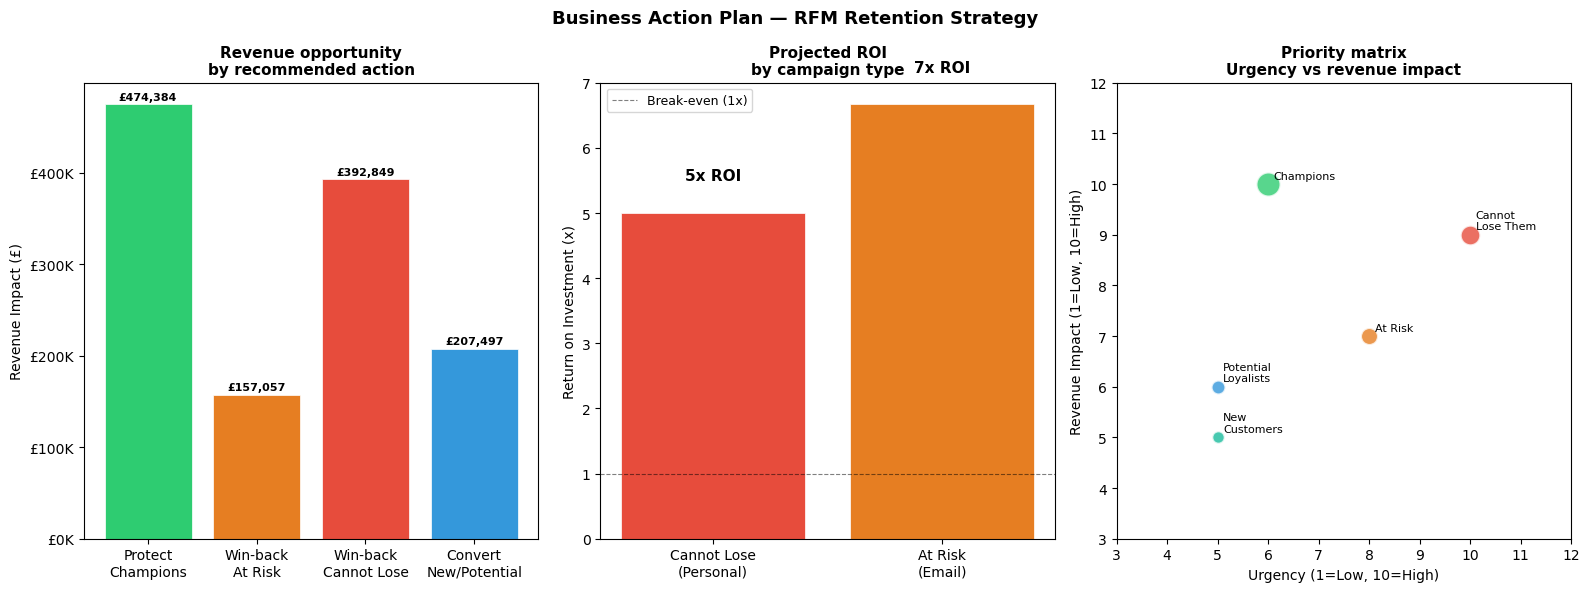

In [13]:


fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Left — Revenue at stake by action
actions = ['Protect\nChampions', 'Win-back\nAt Risk', 'Win-back\nCannot Lose',
           'Convert\nNew/Potential']
values  = [revenue_saved, ar_recovered, cl_recovered, revenue_upside]
colors  = ['#2ecc71', '#e67e22', '#e74c3c', '#3498db']

bars = axes[0].bar(actions, values,
                   color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5000,
        f'£{val:,.0f}',
        ha='center', fontsize=8, fontweight='bold'
    )
axes[0].set_title(
    'Revenue opportunity\nby recommended action',
    fontsize=11, fontweight='bold'
)
axes[0].set_ylabel('Revenue Impact (£)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K')
)

# Middle — ROI comparison
roi_labels  = ['Cannot Lose\n(Personal)', 'At Risk\n(Email)']
roi_values  = [cl_roi, ar_roi]
roi_colors  = ['#e74c3c', '#e67e22']

bars2 = axes[1].bar(roi_labels, roi_values,
                    color=roi_colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars2, roi_values):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{val:.0f}x ROI',
        ha='center', fontsize=11, fontweight='bold'
    )
axes[1].set_title(
    'Projected ROI\nby campaign type',
    fontsize=11, fontweight='bold'
)
axes[1].set_ylabel('Return on Investment (x)')
axes[1].axhline(1, color='black', linestyle='--',
                linewidth=0.8, alpha=0.5, label='Break-even (1x)')
axes[1].legend(fontsize=9)

# Right — Priority matrix (impact vs urgency)
priorities_data = {
    'Cannot\nLose Them':    {'urgency': 10, 'impact': 9,  'size': 200, 'color': '#e74c3c'},
    'At Risk':              {'urgency': 8,  'impact': 7,  'size': 150, 'color': '#e67e22'},
    'Champions':            {'urgency': 6,  'impact': 10, 'size': 300, 'color': '#2ecc71'},
    'Potential\nLoyalists': {'urgency': 5,  'impact': 6,  'size': 100, 'color': '#3498db'},
    'New\nCustomers':       {'urgency': 5,  'impact': 5,  'size': 80,  'color': '#1abc9c'},
}

for label, props in priorities_data.items():
    axes[2].scatter(props['urgency'], props['impact'],
                    s=props['size'], c=props['color'],
                    alpha=0.8, edgecolors='white', linewidth=1.5)
    axes[2].annotate(label,
                     xy=(props['urgency'], props['impact']),
                     xytext=(4, 4), textcoords='offset points',
                     fontsize=8)

axes[2].set_xlabel('Urgency (1=Low, 10=High)')
axes[2].set_ylabel('Revenue Impact (1=Low, 10=High)')
axes[2].set_title(
    'Priority matrix\nUrgency vs revenue impact',
    fontsize=11, fontweight='bold'
)
axes[2].set_xlim(3, 12)
axes[2].set_ylim(3, 12)

plt.suptitle(
    'Business Action Plan — RFM Retention Strategy',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()




In [14]:
# Business Insight

# The final action plan consolidates all previous RFM, cohort, and revenue analyses into a prioritised retention strategy based on both financial 
# impact and expected return on investment.

# The analysis indicates that protecting existing Champions should be the business's highest-value initiative, with an estimated £474,384 in 
# annual revenue protected by reducing Champion churn. Although Champions represent only a small portion of the customer base, they account 
# for the majority of business revenue, making proactive retention critical.

# The second major opportunity is the Cannot Lose Them segment. A targeted personal outreach campaign could potentially recover approximately 
# £392,849 in historical revenue with an estimated 5x return on investment. These customers have already demonstrated high lifetime value,
# making recovery efforts significantly more profitable than acquiring entirely new customers.

# For the broader At Risk segment, a scalable email win-back campaign offers the highest projected efficiency, generating an estimated 7x ROI
# while potentially recovering £157,057 in revenue. This suggests that automated retention campaigns can deliver substantial financial returns at 
# relatively low cost.

# Finally, improving the conversion of New Customers and Potential Loyalists represents a long-term growth opportunity. 
# Increasing average 3-month retention from 21.6% to 40% could generate an estimated £207,497 in additional future revenue, 
# reinforcing the importance of structured onboarding and second-purchase conversion programmes.

# Overall, the priority matrix suggests that the business should allocate resources in the following order:

# Recover high-value inactive customers (Cannot Lose Them).
# Protect Champions through a VIP loyalty programme.
# Execute automated win-back campaigns for At Risk customers.
# Improve early-life retention for new customers through onboarding.

# Summary

In [20]:
# Save recommendations summary for reference
recommendations = pd.DataFrame({
    'Priority':         [1, 2, 3, 4],
    'Segment':          ['Cannot Lose Them', 'At Risk',
                         'Champions', 'New + Potential Loyalists'],
    'Urgency':          ['14 days', '30 days', 'Ongoing', '45 days'],
    'Customers':        [len(cant_lose), ar_count,
                         champ_count, len(new_customers)+len(potential)],
    'Revenue_at_stake': [cant_lose_rev, ar_revenue,
                         champ_total_rev, revenue_upside],
    'Action':           ['Personal outreach', 'Win-back email',
                         'VIP programme', 'Onboarding sequence'],
    'Expected_ROI':     [f'{cl_roi:.0f}x', f'{ar_roi:.0f}x',
                         'Revenue protection', 'Revenue growth']
})

recommendations.to_csv(
    'recommendations.csv', index=False
)

print("Saved: data/processed/recommendations.csv")
print()
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"Headline findings documented:   5")
print(f"Priority recommendations:       4")
print(f"Win-back ROI calculated:        {combined_roi:.0f}x combined")
print(f"Revenue recoverable:            £{total_recoverable:,.0f}")
print(f"Revenue protectable (Champions):£{revenue_saved:,.0f}")
print(f"Charts produced:                1 (chart11_action_plan.png)")


Saved: data/processed/recommendations.csv

SUMMARY
Headline findings documented:   5
Priority recommendations:       4
Win-back ROI calculated:        5x combined
Revenue recoverable:            £549,906
Revenue protectable (Champions):£474,384
Charts produced:                1 (chart11_action_plan.png)


# Project Conclusion

In [17]:
# This analysis of 5,878 customers across the transaction dataset reveals that the business faces two simultaneous challenges that require different 
# strategic responses.

# The first challenge is revenue concentration risk. Just 22.1% of customers (1,297 Champions) generate 68.3% of total revenue (£11.86M). 
# While building a loyal high-value customer base is desirable, this level of concentration creates significant vulnerability. 
# Losing only 5% of Champions would cost the business approximately £592,980 in revenue. 
# A dedicated VIP protection programme is therefore not optional—it represents one of the highest-return investments available to the business.

# The second challenge is customer retention leakage. Average 3-month retention of 21.6% means that the majority of newly acquired customers 
# fail to become repeat buyers. The business is continually investing in customer acquisition while losing many customers before they develop 
# into long-term loyal relationships. Improving the first 90 days of the customer journey is therefore the fastest route to sustainable revenue growth.

# Combined priority actions
# Personal outreach to 223 Cannot Lose Them customers — within 14 days.
# Win-back campaign for 393 At Risk customers — within 30 days.
# VIP loyalty programme for 1,297 Champions — launched within 30 days.
# Structured onboarding sequence for 502 New Customers and Potential Loyalists — over 45 days.

# The first two initiatives alone could recover approximately £549,906 in historical revenue, while a successful Champion protection strategy 
# could safeguard an additional £474,384 annually. The combined win-back programme is projected to generate an estimated 5x return on investment, 
# demonstrating that customer retention initiatives can deliver substantial financial value.

# The analysis provides a clear roadmap for action. High-value inactive customers should be recovered before they are permanently lost, 
# the Champion segment should be proactively protected, and new customers should be guided toward repeat purchases through structured onboarding.

# The data is clear. The actions are specific. The financial impact is measurable. Customer retention is not simply a marketing activity—it is
# one of the highest-return growth strategies available to this business.